In [ ]:
import numpy as np
import matplotlib.pyplot as plt 


Loss Funtion 

In [96]:
def quad_loss(x,y):
    return x**2 + 10*y**2 

gradient of the loss function 

In [97]:
def quad_grad(x,y):
    dx = 2*x
    dy = 20*y
    return np.array([dx,dy])

Gradient Descent (GD)

In [98]:
def gradient_descent(grad_funct,lr,epochs,strat_point):
    x,y = strat_point
    path = [(x,y)]
    losses = [quad_loss(x,y)]
    for _ in range(epochs):
        grad =  grad_funct(x,y) 
        x -= lr*grad[0]
        y -= lr*grad[1]
        path.append((x,y))
        losses.append(quad_loss(x,y))

    return np.array(path),losses
    

Adam optimizer

In [99]:
def adam_optimizer(grad_func , lr ,beta1,beta2,epsilon,epochs,start_point):
    x,y = start_point 
    m  = np.array([0.0,0.0]) 
    v = np.array([0.0,0.0])
    path = [(x,y)]
    losses = [quad_loss(x,y)]
    for t in range (1,epochs+1):
        grad = grad_func(x,y)
        m = beta1 * m+(1-beta1)*grad
        v = beta2 * v +(1-beta2)*(grad**2)

        m_hat = m/(1-beta1**t)
        v_hat = v/(1-beta2**t) 

        # corrected update step
        x -= lr * m_hat[0] / (np.sqrt(v_hat[0]) + epsilon)
        y -= lr * m_hat[1] / (np.sqrt(v_hat[1]) + epsilon)

        path.append((x,y))
        losses.append(quad_loss(x,y))

    return np.array(path) , losses


In [100]:
def plot_paths(function, paths, labels, title):
    X, Y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
    Z = function(X, Y)

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, Z, levels=50, cmap='jet')

    for path, label in zip(paths, labels):
        plt.plot(path[:, 0], path[:, 1], label=label)
        plt.scatter(path[0, 0], path[0, 1], color='green', label="Start")
        plt.scatter(path[-1, 0], path[-1, 1], color='red', label="End")

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


visualization of the loss

In [101]:
def plot_losses(losses, labels, title) :
    plt.figure(figsize=(8, 6))

    for loss, label in zip(losses, labels) :
        plt.plot(loss, label=label)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

Parameters

In [ ]:
lr_gd = 0.1 # Learning rate for GD
lr_adam = 0.1 # Learning rate for Adam
beta1 = 0.9 # Beta1 for Adam
beta2 = 0.999 # Beta2 for Adam
epsilon = 1e-8 # Small constant for Adam
epochs = 100    
start_point = (1.5, 1.5)  

Rum optimzation 


In [103]:
path_gd , losses_gd =   gradient_descent(quad_grad,lr_gd,epochs,strat_point=start_point)
path_adma , losses_adam = adam_optimizer(quad_grad,lr_adam,beta1,beta2,epsilon,epochs,start_point)

visualization of the optimerzers 

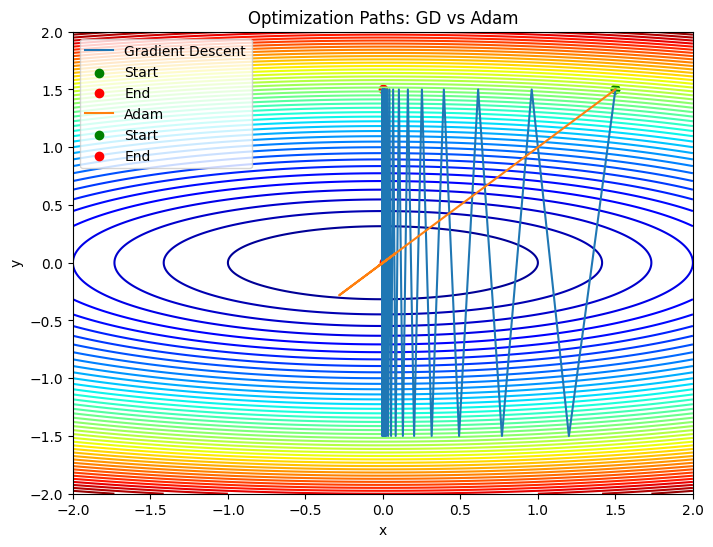

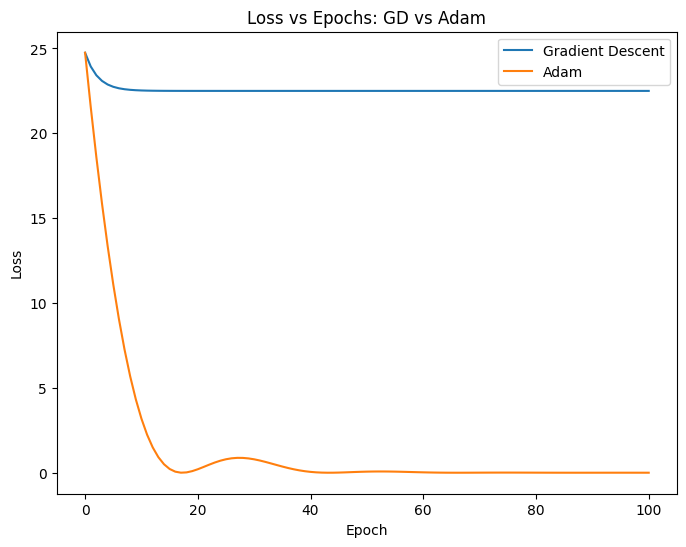

In [104]:
plot_paths(quad_loss,[path_gd,path_adma],["Gradient Descent", "Adam"],
"Optimization Paths: GD vs Adam") 
plot_losses([losses_gd,losses_adam],["Gradient Descent", "Adam"],
"Loss vs Epochs: GD vs Adam")